In [1]:
'''
Read a set of datafiles, each containing datawords obtained by putting a sweep of 
voltages (1.8V to 0) into the ADC bypassing the CSA. These voltages should result
in a good dataword range from 200 to 800 or so. Two arrays are created and written
to a file for later analysis:
    pkt_count: logs the # of packets in each word bin by channel
    too_few: logs the # of word bins with < 2 packets by channel
'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math
import tqdm

from tqdm import tqdm
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime

##########################################################
# Initialize parameters  
##########################################################

# set1-7 datafiles
#filename = "../data/packet-warm_lin_t2_10kcycles_600s_2.37.hdf5"
#filename = "../data/packet-warm_lin_t2_file2_10kcycles_600s.hdf5"
#filename = "../data/packet-warm_lin_t2_10kcycles_600s_0.7sramp.hdf5"
#filename = "../data/packet-warm_lin_t2_10kcycles_600s_9.7sramp.hdf5"
#filename = "../data/packet-warm_lin_t2_10kcycles_10ks_9.77ramp_file2.hdf5"
#filename = "../data/packet-warm_lin_t2_10kcycles_1200s_varied_ramp.hdf5"
#filename = "../data/packet-warm_lin_t2_10kcycles_1200s_9.77ramp.hdf5"
#filename = "../data/packet-warm_lin_t2_10kcycles_1200s_varied_ramp2.hdf5"

#files = ["../data/packet-warm_lin_t2_10kcycles_1200s_varied_ramp2.hdf5", \
#          "../data/packet-warm_lin_t2_10kcycles_1200s_varied_ramp.hdf5" ]

#files = ["../data/packet-warm_lin_t2_10kcycles_1200s_9.77ramp.hdf5", \
#         "../data/packet-warm_lin_t2_10kcycles_1200s_2.37sramp.hdf5" ]

#files = ["../data/packet-warm_lin_t2_10kcycles_1200s_9.77ramp.hdf5", \
#         "../data/packet-warm_lin_t2_10kcycles_600s_9.7sramp.hdf5", \
#         "../data/packet-warm_lin_t2_10kcycles_800s_9.77ramp_file2.hdf5" ]

#files = ["../data/packet-warm_lin_t2_10kcycles_1200s_9.77ramp.hdf5"]

#files = ["../data/packet-warm_lin_t2_10kcycles_1200s_120sramp_post_fix.hdf5", \
#         "../data/packet-warm_lin_t2_10kcycles_600s_120sramp_post_fix_file2.hdf5" ]

files = ["../data/packet-warm_lin_t2_10kcycles_1200s_9.77_2.37ramp_post_fix.hdf5", \
         "../data/packet-warm_lin_t2_10kcycles_1200s_9.77_2.37ramp_post_fix_file2.hdf5" ]

#files = ["../data/packet-warm_lin_t2_10kcycles_1200s_120sramp.hdf5", \
#         "../data/packet-warm_lin_t2_10kcycles_1200s_120sramp_file2.hdf5" ]

#files = ["../data/packet-warm_lin_t2_10kcycles_1200s_no_ramp_post_fix.hdf5"]
#         "../data/packet-warm_lin_t2_10kcycles_1200s_no_ramp_post_fix_file2.hdf5" ]

# only tile 10 powered up, cold tests
#files = [ "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_lin_10kcycles_600s_t10_2.37ramp.hdf5", \
#          "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_lin_10kcycles_600s_t10_9.77ramp.hdf5" ]

ramp = "9.77_2.37"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
#tiles = [1,2,3,4,5,6,7,8,9,10]
tiles = [10]

# serial numbers for set1 of 10 tiles
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101', '4K00277', '4K03329', '4K04087' ]

# set the range of datawords to test
max_dataword = 800
min_dataword = 260

# initialize
ig = 1 
first_tile = True
n_chan_total = 0  
mean_list = []
pkt_count     = [[[0 for wrd in range(1023)] for chn in range(64)] for chp in range(256)]
too_few       = [[0 for chn in range(64)] for chp in range(256)]
std_pkt_count = [[0 for chn in range(64)] for chp in range(256)]

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp'

In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def get_data(files, tile, ig):
    
    global chip_serial_number_list, ramp, pkt_count, \
    too_few, chip_serial_number, temp, total_livetime, temp, max_dataword
    
    # initialize at the tile level
    first_chan = True
    verbose = False
    first_file = True

    chip_serial_number = chip_serial_number_list[tile]    
    
    # read packet data from each file 
    for filename in files:

        if first_file:
            first_file = False
            
            # read packets from the file
            f = h5py.File(filename, 'r')
            packets = f['packets'][:]

            # create arrays of data packets
            data_mask = f['packets'][:]['packet_type']  == 1
            data_pkts = packets[data_mask]

            # determine the runtime of the file
            unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
            livetime = np.max(unixtime)-np.min(unixtime)        

            total_livetime = livetime
            
            print(f"\t{len(data_pkts):,} data packets gathered over {livetime}s in {filename}")

            # determine if this was a warm or cold data run (info for filename)
            if "warm" in filename:
                temp = "warm"
            elif "cold" in filename:
                temp = "cold"
            else:
                print(f"Problem: the file name does not indicate warm or cold")
                temp = "unknown_temperature"     
        
        else:
            f = h5py.File(filename, 'r')
            packets = f['packets'][:]
            data_mask = f['packets'][:]['packet_type']  == 1
            extra_data_pkts = packets[data_mask]

            unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
            livetime = np.max(unixtime)-np.min(unixtime)        

            total_livetime += livetime
            
            print(f"\t{len(extra_data_pkts):,} data packets gathered over {livetime}s in {filename}")            

            data_pkts = np.concatenate( (data_pkts, extra_data_pkts), axis=0 )
    
    # get a list of the io_channels that could be enabled for a given tile
    io_channel_ids = get_io_channels(tile)

    print(f"\tTile {tile}, masking for IO_channels: {io_channel_ids}")
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]
    
    # check for tiles with no data    
    if len(data_pkts) ==0: 
        print(f'There are no data packets for tile {tile}')        
        return

    # remove data packets with zero datawords
    non_zero_pkts = data_pkts[data_pkts['dataword'] != 0]
    
    # populate lists/arrays containing the # of packets in each word bin per channel
    for chip in tqdm(range(11,171), desc = "counting pkts by chip"):
        
        # mask for chip
        chip_mask = non_zero_pkts['chip_id'] == chip
        chip_pkts = non_zero_pkts[chip_mask]     

        if len(chip_pkts) == 0:
            print(f"There are 0 non-zero packets in chip {chip}")
            continue
        
        for chan in range(64):

            # initialize at channel level
            too_few_chan = 0

            # mask for channel    
            chan_mask = chip_pkts['channel_id'] == chan
            chan_adc = chip_pkts[chan_mask]['dataword'][:]            
        
            if len(chan_adc) == 0:
                print(f"There are 0 non-zero packets in chip-chan {chip}-{chan}")
                continue
                
            # record bin counts
            for word in range(min_dataword, max_dataword):

                pkt_count[chip][chan][word] = chan_adc.tolist().count(word)

                # count how many bins have < 2 packets
                if pkt_count[chip][chan][word] < 2:
                    too_few_chan +=1

            too_few[chip][chan] = too_few_chan
    
    return

In [4]:
def find_best_and_worst():
    
    global pkt_count, too_few, best_chip, worst_chip

    lowest_few  = 1E7
    most_few = 0
    best_chip = 0
    worst_chip = 0
    
    # find best and worst word-bin populated chips
    for chip in range(11,171):

        too_few_chip = 0
        
        for chan in range(0,64):
            too_few_chip = too_few_chip + too_few[chip][chan]

        if too_few_chip < lowest_few:
            best_chip = chip
            lowest_few = too_few_chip
            
        if too_few_chip > most_few:
            worst_chip = chip
            most_few = too_few_chip

    if best_chip > 0:
        print(f"\nBest  Chip {best_chip } had {lowest_few} word bins w < 2 pkts")
    else:
        print(f"\nNo best chip could be found")

    if worst_chip > 0:    
        print(f"\nWorst Chip {worst_chip} had {most_few } word bins w < 2 pkts, among its channels:")    
    else:
        print(f"\nNo worst chip could be found")
        
    lowest_few  = 1000
    most_few = -1
    best_chan = 100
    worst_chn = 100
    
    # find best and worst channels on worst chip    
    for chan in range(0,64):
        
        if too_few[worst_chip][chan] < lowest_few:
            best_chan = chan
            lowest_few = too_few[worst_chip][chan]

        if too_few[worst_chip][chan] > most_few:
            worst_chan = chan
            most_few = too_few[worst_chip][chan]

    if best_chan < 100:
        print(f"\tBest  Channel {best_chan } had {lowest_few} bins w < 2 pkts")
    else:
        print(f"\nNo best channel could be found")

    if worst_chan < 100:    
        print(f"\tWorst Channel {worst_chan} had {most_few } bins w < 2 pkts")    
    else:
        print(f"\nNo worst channel could be found")   
    
    return best_chip, worst_chip, best_chan, worst_chan


In [5]:
def graph_tile(tile):

    global pkt_count, too_few, ramp, chip_serial_number_list, temp

    chip_serial_number = chip_serial_number_list[tile]
    too_few_list, chip_list = [], []
    
    for chip in range(11,171):
        count_list = np.array(too_few[chip]).flatten()
        too_few_list.append(np.sum(count_list))
        chip_list.append(chip)

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(chip_list, too_few_list)
    ax.set_title(f'# Word Bins w < 2 pkts by Chip on Tile {tile}\n {ramp}s Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Chip')
    ax.set_ylabel(f'# Word Bins w < 2 pkts')
    plt.show 
    
    flatten_by_chip = np.array(too_few).flatten()
    too_few_list = flatten_by_chip.flatten()

    n_chans = len(too_few_list)
    n_5_chans = sum(1 for x in too_few_list if x < 5)
    n_0_chans = sum(1 for x in too_few_list if x == 0)
    
    print(f"\n{100 * n_5_chans / n_chans:.0f}% of channels on Tile {tile} have  < 5 sparse word bins")
    print(f"{100 * n_0_chans / n_chans:.0f}% of channels on Tile {tile} have zero sparse word bins")    
    
    mx = max(too_few_list)
    mn = min(too_few_list)
    print(f"The smallest # of word-bins with too few packets in 1 channel = {mn}")
    print(f"The largest  # of word-bins with too few packets in 1 channel = {mx}")
    n_bins = int(mx - mn +1)  
          
    fig, ax = plt.subplots(1,2, figsize=(14, 3))
    ax[0].hist(too_few_list, bins=n_bins)
    ax[0].set_title(f'# Word Bins w < 2 pkts per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[0].set_xlabel(f'# Word Bins < 2 pkts')
    ax[0].set_ylabel(f'Channel Count')
    ax[0].set_yscale("log")

    ax[1].hist(too_few_list, bins=n_bins)
    ax[1].set_title(f'# Word Bins w < 2 pkts per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[1].set_xlabel(f'# Word Bins < 2 pkts')
    ax[1].set_xlim(0,20)
    ax[1].set_yscale("log")
    
    plt.show 



In [6]:
def graph_chip(tile, chip, quality):
    
    global pkt_count, too_few, chip_serial_number_list

    chip_serial_number = chip_serial_number_list[tile]
    
    too_few_list, chan_list = [],[]
    
    for chan in range(0,64):
    
        too_few_list.append(too_few[chip][chan])
        chan_list.append(chan)
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(chan_list, too_few_list)
    ax.set_title(f'Word-bins w < 2 pkts by Channel on {quality} Chip {chip}\nTest of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Channel')
    ax.set_ylabel(f'# Word-bins w < 2 pkts')
    plt.show                 

    return

In [7]:
def graph_channel(tile, chip, chan, quality):

    global pkt_count, chip_serial_number_list

    chip_serial_number = chip_serial_number_list[tile]
    
    count_list, word_list = [],[]

    looking = True
    
    for word in range(250, 800):

        if pkt_count[chip][chan][word] > 0 and looking:
            looking = False

        if not looking:
            count_list.append(pkt_count[chip][chan][word])
            word_list.append(word)
    
    n_low = sum(1 for x in count_list if x<2)
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(word_list, count_list)
    ax.set_title(f'# Pkts in Word bins for {quality} Channel {chan} on Chip {chip}\n{n_low} bins have < 2pkts, Test of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'ADC Dataword')
    ax.set_ylabel(f'# Packets')
    plt.show

    return    

In [8]:
def get_std_pkt_count(tile):
    
    global pkt_count, std_pkt_count, ramp, chip_serial_number_list, min_dataword, max_dataword

    std_list = []

    chip_serial_number = chip_serial_number_list[tile]
    
    for chip in range(62,63):
        for chan in range(0,64):
            word_counts = []
            for word in range(min_dataword, max_dataword):
                word_counts.append(pkt_count[chip][chan][word])
            #word_counts = np.array(pkt_count[chip][chan]).flatten()
            std_chan = np.std(word_counts)
            std_pkt_count[chip][chan] = std_chan
            std_list.append(std_chan)

    mx = max(std_list)
    mn = min(std_list)
    
    fig, ax = plt.subplots(1,2, figsize=(14, 3))

    ax[0].hist(std_list, bins = 100)
    ax[0].set_title(f'Stdev(Word Bin Count) per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[0].set_xlabel(f'Stdev(Word Bin Count)')
    ax[0].set_ylabel(f'Channel Count')
    ax[0].set_yscale("log")

    ax[1].hist(std_list, bins = 100)
    ax[1].set_title(f'Stdev(Word Bin Count) per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[1].set_xlabel(f'Stdev(Word Bin Count)')
    ax[1].set_yscale("log")
    ax[1].set_xlim(0,25)
    
    plt.show 

In [9]:
def write_data_to_file(pkt_count, too_few):

    global total_livetime, file, ramp, temp, chip_serial_number, total_livetime

    run_minutes = int(total_livetime/60)
    
    filename = f'../data/linearity_data_{temp}_tile{tile}_{chip_serial_number}_{ramp}ramp_{run_minutes}m.hdf5'
    
    with h5py.File(filename, 'w') as f:
            
        f.create_dataset('too_few', data = too_few, dtype=int)
        f.create_dataset('pkt_count', data = pkt_count, dtype=int)
        
        f.close()  

    print(f"\n\nData written to {filename}\n\n")
    
    return    

In [10]:
def find_1st_good_channel(tile):

    global too_few

    looking = True
    
    for chip in range(11,171):
        if looking:
            for chan in range(0,64):                
                if looking and too_few[chip][chan] ==0:                
                    graph_channel(tile, chip, chan, "1st Good")
                    print(f"Chip-Chan {chip}-{chan} is 1st channel with 0 empty word bins")
                    looking = False

    if looking:
        print(f"No channel could be found with all data words populated by at least 2 pkts")

In [11]:
####################
# main
####################

print(f'Run Statistics for {len(files)} Data Files:')

# use the filename of the 1st file to determine the tile tested in these runs
filename = files[0]

if "_t1_" in filename:
    tile = 1
elif "_t2_" in filename:
    tile = 2
elif "_t3_" in filename:
    tile = 3
elif "_t4_" in filename:
    tile = 4
elif "_t5_" in filename:
    tile = 5
elif "_t6_" in filename:
    tile = 5
elif "_t7_" in filename:
    tile = 7
else:
    print("PROBLEM: the tile # is not identified in the datafile name")

chip_serial_number = chip_serial_number_list[tile]

get_data(files, tile, ig)

Run Statistics for 2 Data Files:
	106,320,457 data packets gathered over 1182s in ../data/packet-warm_lin_t2_10kcycles_1200s_9.77_2.37ramp_post_fix.hdf5
	105,479,389 data packets gathered over 1181s in ../data/packet-warm_lin_t2_10kcycles_1200s_9.77_2.37ramp_post_fix_file2.hdf5
	Tile 2, masking for IO_channels: [5, 6, 7, 8]


counting pkts by chip: 100%|████████████████| 160/160 [23:37<00:00,  8.86s/it]



87% of channels on Tile 2 have  < 5 sparse word bins
39% of channels on Tile 2 have zero sparse word bins
The smallest # of word-bins with too few packets in 1 channel = 0
The largest  # of word-bins with too few packets in 1 channel = 270

Best  Chip 78 had 155 word bins w < 2 pkts

Worst Chip 62 had 434 word bins w < 2 pkts, among its channels:
	Best  Channel 9 had 0 bins w < 2 pkts
	Worst Channel 40 had 270 bins w < 2 pkts


Data written to ../data/linearity_data_warm_tile2_4k603591_9.77_2.37ramp_39m.hdf5


Chip-Chan 11-36 is 1st channel with 0 empty word bins


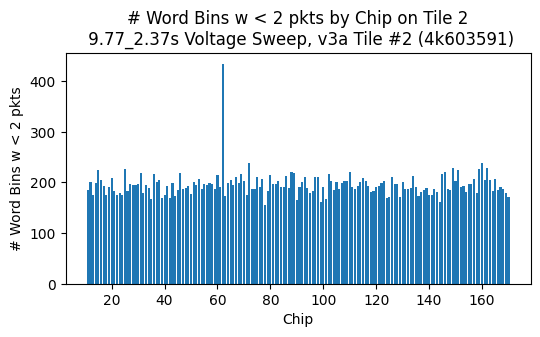

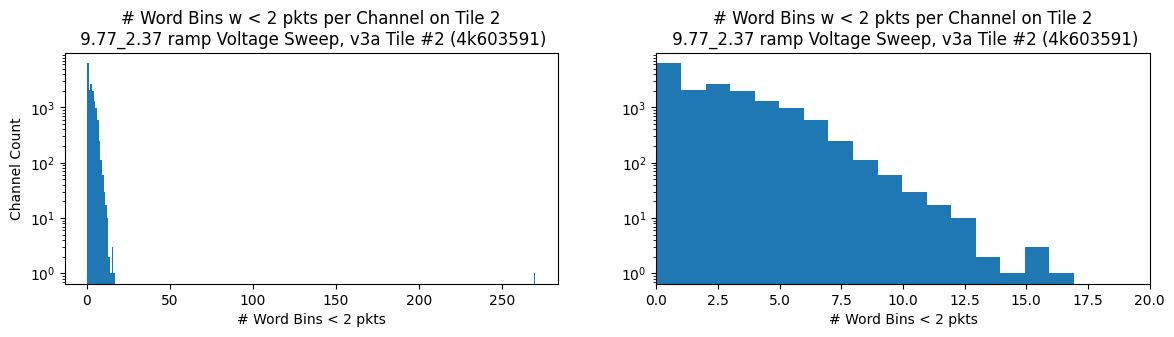

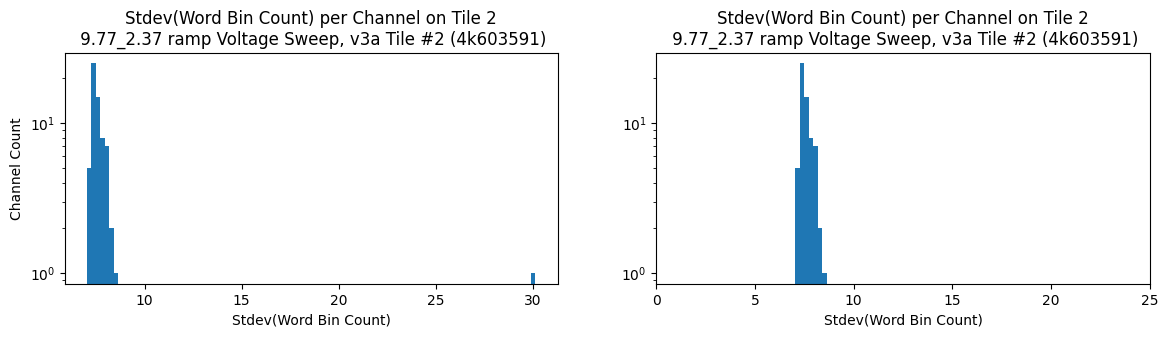

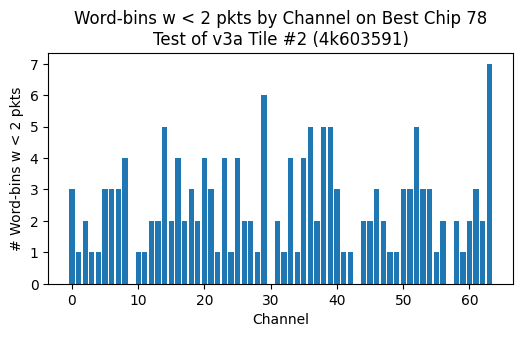

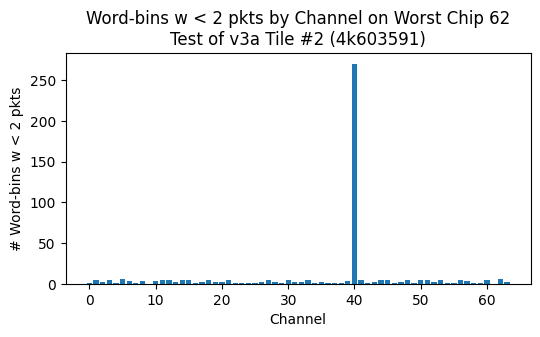

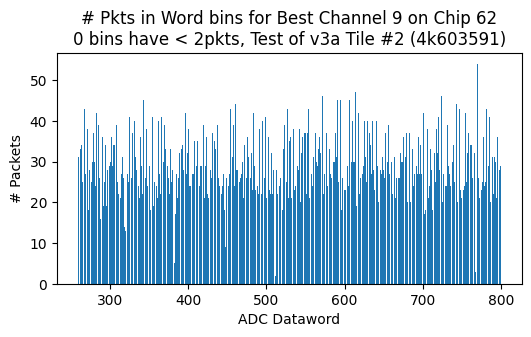

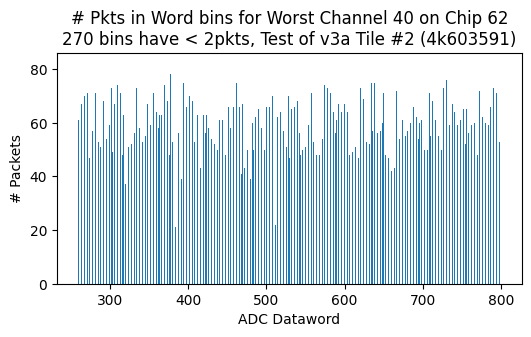

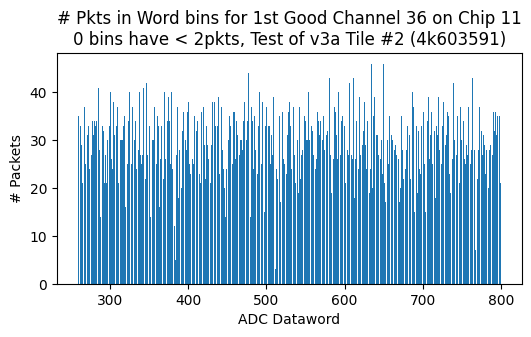

In [12]:
# make various graphs

graph_tile(tile)

best_chip, worst_chip, best_chan, worst_chan = find_best_and_worst()

get_std_pkt_count(tile)

graph_chip(tile, best_chip, "Best")
graph_chip(tile, worst_chip, "Worst")
graph_channel(tile, worst_chip, best_chan, "Best")
graph_channel(tile, worst_chip, worst_chan, "Worst")

write_data_to_file(pkt_count, too_few)

find_1st_good_channel(tile)
